# Giai đoạn 5 — Gộp dữ liệu và gán trọng số mẫu

Gộp **574 phiếu khảo sát thật** (phần train) với **13.796 dòng tổng hợp** từ Giai đoạn 4 thành
tập huấn luyện cuối cùng.

## Vấn đề: hai loại mất cân bằng cùng lúc

1. **Mất cân bằng nguồn** — dòng tổng hợp nhiều gấp 24 lần dòng thật. Nếu để nguyên, mô hình sẽ
   chủ yếu học đặc điểm của dữ liệu do máy sinh chứ không phải của người thật.
2. **Mất cân bằng lớp** — ngành nhiều dữ liệu gấp 4 lần ngành ít. Ngành hiếm dễ bị mô hình bỏ qua.

Hai vấn đề này **khác nhau** và cần hai cơ chế riêng. Trọng số cuối cùng là tích của cả hai:

$$w = \underbrace{w_{\text{nguồn}}}_{\text{thật đáng tin hơn tổng hợp}} \times
      \underbrace{w_{\text{lớp}}}_{\text{ngành hiếm không bị lấn át}}$$

### Trọng số nguồn — cân bằng tổng ảnh hưởng của hai nguồn

$$w_{\text{nguồn}}^{\text{thật}} = \frac{n_{\text{tổng hợp}}}{n_{\text{thật}}}, \qquad
  w_{\text{nguồn}}^{\text{tổng hợp}} = 1$$

Con số này **tính ra từ dữ liệu**, không đặt tay. Sau khi nhân, tổng trọng số của 574 dòng thật
đúng bằng tổng trọng số của 13.796 dòng tổng hợp — hàm mất mát chịu ảnh hưởng ngang nhau từ hai nguồn.

### Trọng số lớp — cân bằng theo căn bậc hai

$$w_{\text{lớp}}(c) = \left(\frac{\overline{W}}{W_c}\right)^{\alpha}, \qquad \alpha = 0.5$$

Cân bằng hoàn toàn ($\alpha = 1$) sẽ thổi trọng số của ngành chỉ có 5 phiếu lên quá cao, khiến mô
hình học thuộc lòng vài dòng lẻ. $\alpha = 0.5$ là mức dung hoà tiêu chuẩn: nâng ngành hiếm lên
nhưng không cực đoan.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

SPLIT_DIR  = Path("../data/processed/02_split")
SYNTH_DIR  = Path("../data/processed/04_synthetic")
OUTPUT_DIR = Path("../data/processed/05_final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_LOP, TY_LE_NGUON = 0.5, 1.0

LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
DIEM_COLS = ["diem_Toan", "diem_Ly", "diem_Hoa", "diem_Anh", "diem_Van",
             "diem_Su", "diem_Sinh", "diem_Dia", "diem_Gdktpl", "diem_Tin"]
COT_CHUNG = (["ma_nganh", "nganh_hoc", "ma_khoi_nganh", "ten_khoi_nganh", "to_hop_thi", "gioi_tinh"]
             + LIKERT_COLS + DIEM_COLS + ["muc_tieu_ma", "muc_tieu_nhan"])

TAX = json.load(open(SPLIT_DIR / "nganh_khoi_mapping.json", encoding="utf-8"))
MA_TO_TEN = {int(k): v for k, v in TAX["ma_to_ten"].items()}
TEN_KHOI  = {int(k): v for k, v in TAX["ten_khoi"].items()}

df_that  = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
df_synth = pd.read_csv(SYNTH_DIR / "synthetic_GA_data.csv")
for d in (df_that, df_synth):
    d["gioi_tinh"] = d["gioi_tinh"].astype(str).str.strip().replace({"Nữ": "Nu"})
df_that["nguon_du_lieu"], df_synth["nguon_du_lieu"] = "khaosat_that", "synthetic_GA"

for ten, d in [("khảo sát thật", df_that), ("tổng hợp GA", df_synth)]:
    thieu = set(COT_CHUNG) - set(d.columns)
    assert not thieu, f"{ten} thiếu cột: {thieu}"

print(f"Khảo sát thật : {len(df_that):>6,} dòng")
print(f"Tổng hợp GA   : {len(df_synth):>6,} dòng")
print(f"Tỷ lệ         : 1 : {len(df_synth)/len(df_that):.0f}")

Khảo sát thật :    574 dòng
Tổng hợp GA   : 13,796 dòng
Tỷ lệ         : 1 : 24


In [2]:
df = pd.concat([df_that[COT_CHUNG + ["nguon_du_lieu"]],
                df_synth[COT_CHUNG + ["nguon_du_lieu"]]], ignore_index=True)
df["is_real"] = (df["nguon_du_lieu"] == "khaosat_that").astype(int)
n_that, n_synth = int(df.is_real.sum()), int((1 - df.is_real).sum())

# (1) Trọng số nguồn
w_that = TY_LE_NGUON * n_synth / n_that
df["w_nguon"] = np.where(df.is_real == 1, w_that, 1.0)

# (2) Trọng số lớp
W_lop = df.groupby("ma_nganh")["w_nguon"].sum()
w_lop = (W_lop.mean() / W_lop) ** ALPHA_LOP
df["w_lop"] = df["ma_nganh"].map(w_lop)

# (3) Trọng số cuối, chuẩn hoá về trung bình 1
df["sample_weight"] = df["w_nguon"] * df["w_lop"]
df["sample_weight"] /= df["sample_weight"].mean()

print("BẢNG 5.1 — Trọng số mẫu\n")
print(f"  Trọng số nguồn — dòng thật     : {w_that:>8.2f}")
print(f"  Trọng số nguồn — dòng tổng hợp : {1.0:>8.2f}")
print(f"  Tổng trọng số nguồn — thật     : {df.loc[df.is_real==1,'w_nguon'].sum():>8,.0f}")
print(f"  Tổng trọng số nguồn — tổng hợp : {df.loc[df.is_real==0,'w_nguon'].sum():>8,.0f}")
print(f"\n  Trọng số lớp (α = {ALPHA_LOP}):")
print(f"     nhỏ nhất {w_lop.min():.2f}  ({MA_TO_TEN[w_lop.idxmin()]})")
print(f"     lớn nhất {w_lop.max():.2f}  ({MA_TO_TEN[w_lop.idxmax()]})")
print(f"\n  Trọng số cuối cùng: nhỏ nhất {df.sample_weight.min():.3f}  |  "
      f"trung vị {df.sample_weight.median():.3f}  |  lớn nhất {df.sample_weight.max():.2f}")

BẢNG 5.1 — Trọng số mẫu

  Trọng số nguồn — dòng thật     :    24.03
  Trọng số nguồn — dòng tổng hợp :     1.00
  Tổng trọng số nguồn — thật     :   13,796
  Tổng trọng số nguồn — tổng hợp :   13,796

  Trọng số lớp (α = 0.5):
     nhỏ nhất 0.67  (Công nghệ thông tin)
     lớn nhất 1.62  (Công nghệ kỹ thuật môi trường)

  Trọng số cuối cùng: nhỏ nhất 0.361  |  trung vị 0.479  |  lớn nhất 20.86


In [3]:
# --- Kiểm tra bắt buộc --------------------------------------------------------
assert len(df) == n_that + n_synth
assert df["ma_nganh"].nunique() == 39, "Phải đủ 39 ngành"
assert set(df["ma_khoi_nganh"]) == set(range(7)), "Phải đủ 7 khối"
assert df["sample_weight"].gt(0).all(), "Trọng số phải dương"
assert df[LIKERT_COLS].notna().all().all(), "Likert không được rỗng"
assert set(df["gioi_tinh"].unique()) <= {"Nam", "Nu"}, f"Giới tính lạ: {set(df.gioi_tinh)}"
assert (df[DIEM_COLS].notna().sum(axis=1) == 3).all(), "Mỗi dòng phải có đúng 3 điểm"

trung = df.duplicated(subset=LIKERT_COLS + DIEM_COLS + ["ma_nganh"]).mean()
df.to_csv(OUTPUT_DIR / "train_final.csv", index=False, encoding="utf-8-sig")

print(f"✅ train_final.csv — {len(df):,} dòng × {df.shape[1]} cột")
print(f"   khảo sát thật {n_that:,} ({n_that/len(df):.1%})  |  "
      f"tổng hợp GA {n_synth:,} ({n_synth/len(df):.1%})")
print(f"   Tỷ lệ dòng trùng hoàn toàn: {trung:.2%} (giữ nguyên, không xoá)")

✅ train_final.csv — 14,370 dòng × 33 cột
   khảo sát thật 574 (4.0%)  |  tổng hợp GA 13,796 (96.0%)
   Tỷ lệ dòng trùng hoàn toàn: 0.01% (giữ nguyên, không xoá)


   💾 Đã lưu hình: hinh_5_1_trong_so_nguon.png


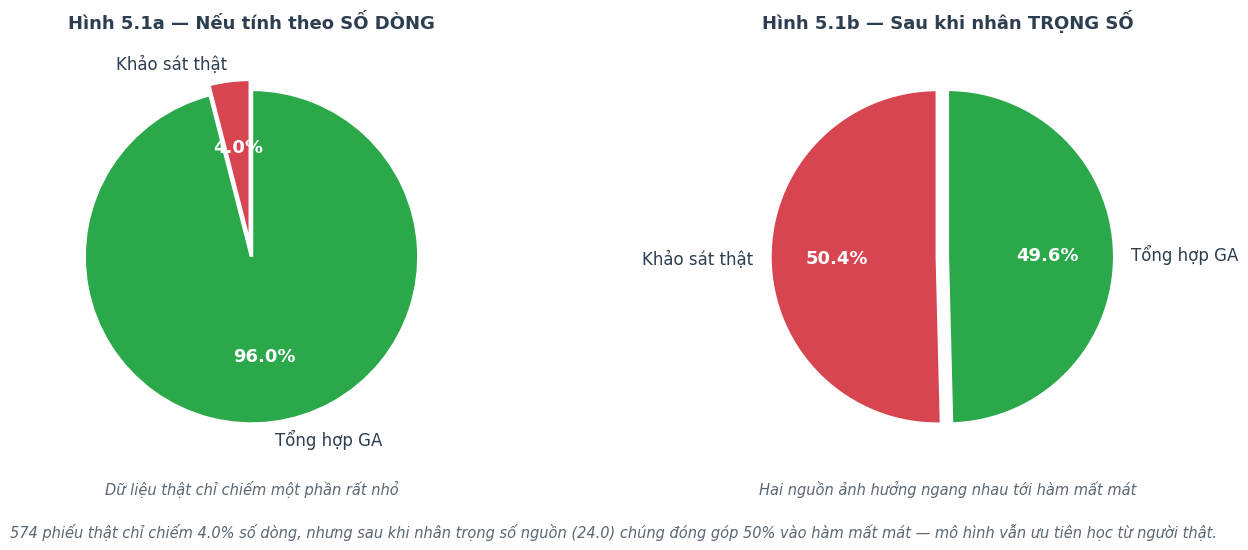

In [4]:
# ═══════════ HÌNH 5.1 — Trọng số nguồn kéo lại cân bằng ═══════════
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

for ax, (gt, tieu_de, ghi) in zip(axes, [
    ([n_that, n_synth], "Hình 5.1a — Nếu tính theo SỐ DÒNG",
     "Dữ liệu thật chỉ chiếm một phần rất nhỏ"),
    ([df.loc[df.is_real == 1, "sample_weight"].sum(),
      df.loc[df.is_real == 0, "sample_weight"].sum()],
     "Hình 5.1b — Sau khi nhân TRỌNG SỐ",
     "Hai nguồn ảnh hưởng ngang nhau tới hàm mất mát"),
]):
    tong = sum(gt)
    w, t, a = ax.pie(gt, labels=["Khảo sát thật", "Tổng hợp GA"],
                     colors=[C_THAT, C_GA], startangle=90,
                     autopct=lambda p: f"{p:.1f}%", explode=(0.06, 0),
                     textprops={"fontsize": 12}, wedgeprops={"edgecolor": "white", "linewidth": 2.5})
    for x in a:
        x.set_color("white"); x.set_fontweight("bold"); x.set_fontsize(13)
    ax.set_title(tieu_de)
    ax.text(0, -1.42, ghi, ha="center", fontsize=10.5, color="#5A6672", style="italic")

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_5_1_trong_so_nguon.png",
    f"574 phiếu thật chỉ chiếm {n_that/len(df):.1%} số dòng, nhưng sau khi nhân trọng số nguồn "
    f"({w_that:.1f}) chúng đóng góp 50% vào hàm mất mát — mô hình vẫn ưu tiên học từ người thật.")
plt.show()

   💾 Đã lưu hình: hinh_5_2_trong_so_lop.png


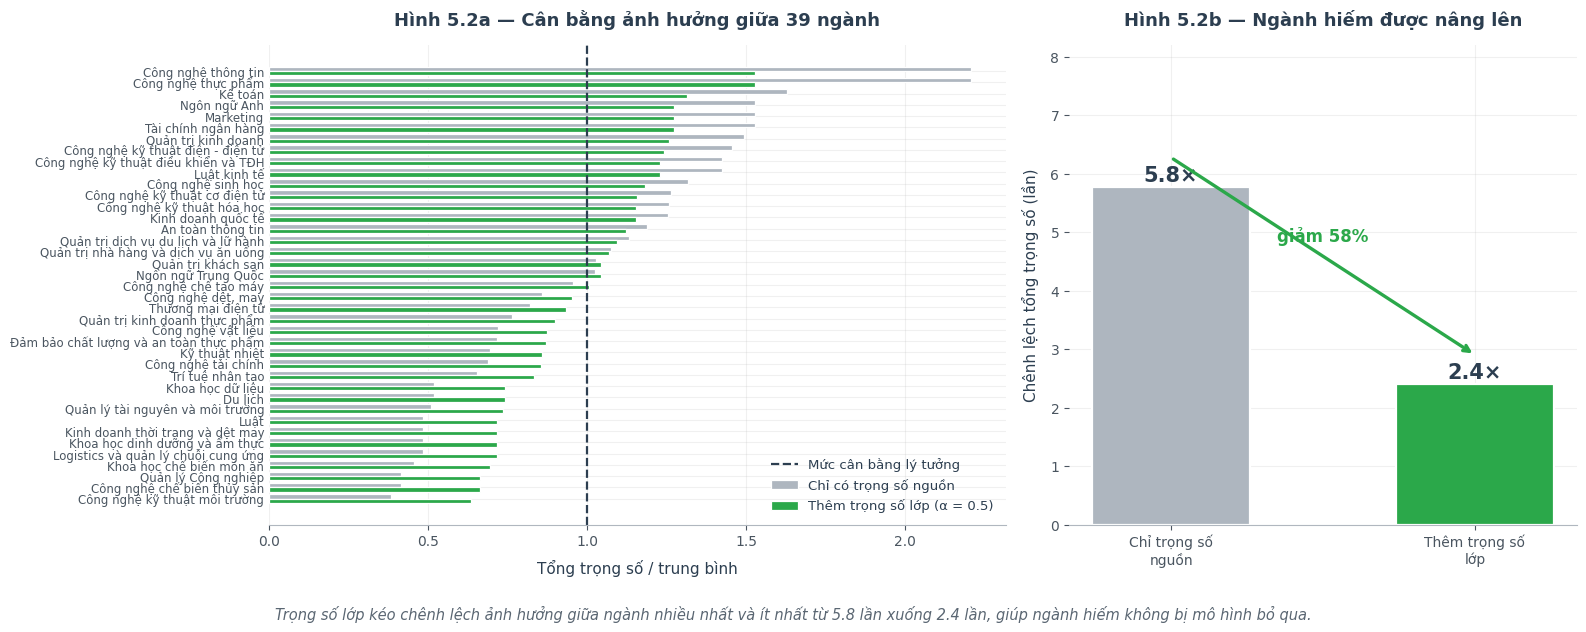

In [5]:
# ═══════════ HÌNH 5.2 — Trọng số lớp ═══════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.45, 1]})

# (a) Tổng trọng số theo ngành, trước và sau cân bằng lớp
ax = axes[0]
truoc = df.groupby("ma_nganh")["w_nguon"].sum()
sau   = df.groupby("ma_nganh")["sample_weight"].sum()
thu_tu = truoc.sort_values().index
y = np.arange(39); h = 0.38
ax.barh(y + h/2, (truoc[thu_tu] / truoc.mean()).values, h,
        label="Chỉ có trọng số nguồn", color=C_XAM, edgecolor="white", linewidth=0.9)
ax.barh(y - h/2, (sau[thu_tu] / sau.mean()).values, h,
        label=f"Thêm trọng số lớp (α = {ALPHA_LOP})", color=C_GA,
        edgecolor="white", linewidth=0.9)
ax.axvline(1.0, color=C_DAM, ls="--", lw=1.6, label="Mức cân bằng lý tưởng")
ax.set_yticks(y); ax.set_yticklabels([MA_TO_TEN[m] for m in thu_tu], fontsize=8.5)
ax.set_xlabel("Tổng trọng số / trung bình")
ax.set_title("Hình 5.2a — Cân bằng ảnh hưởng giữa 39 ngành")
ax.legend(loc="lower right", fontsize=9.5); ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# (b) Mức độ chênh lệch thu hẹp
ax = axes[1]
ch_truoc = truoc.max() / truoc.min()
ch_sau   = sau.max() / sau.min()
bars = ax.bar(["Chỉ trọng số\nnguồn", "Thêm trọng số\nlớp"], [ch_truoc, ch_sau],
              color=[C_XAM, C_GA], width=0.52, edgecolor="white", linewidth=1.6)
for i, v in enumerate([ch_truoc, ch_sau]):
    ax.text(i, v + 0.09, f"{v:.1f}×", ha="center", fontsize=15, fontweight="bold", color=C_DAM)
ax.annotate("", xy=(1, ch_sau + 0.5), xytext=(0, ch_truoc + 0.5),
            arrowprops={"arrowstyle": "->", "lw": 2.4, "color": C_GA})
ax.text(0.5, (ch_truoc + ch_sau) / 2 + 0.75, f"giảm {1 - ch_sau/ch_truoc:.0%}",
        ha="center", fontsize=12, fontweight="bold", color=C_GA)
ax.set_ylabel("Chênh lệch tổng trọng số (lần)")
ax.set_ylim(0, ch_truoc * 1.42)
ax.set_title("Hình 5.2b — Ngành hiếm được nâng lên")
ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_5_2_trong_so_lop.png",
    f"Trọng số lớp kéo chênh lệch ảnh hưởng giữa ngành nhiều nhất và ít nhất từ {ch_truoc:.1f} lần "
    f"xuống {ch_sau:.1f} lần, giúp ngành hiếm không bị mô hình bỏ qua.")
plt.show()

   💾 Đã lưu hình: hinh_5_3_co_cau_tap_huan_luyen.png


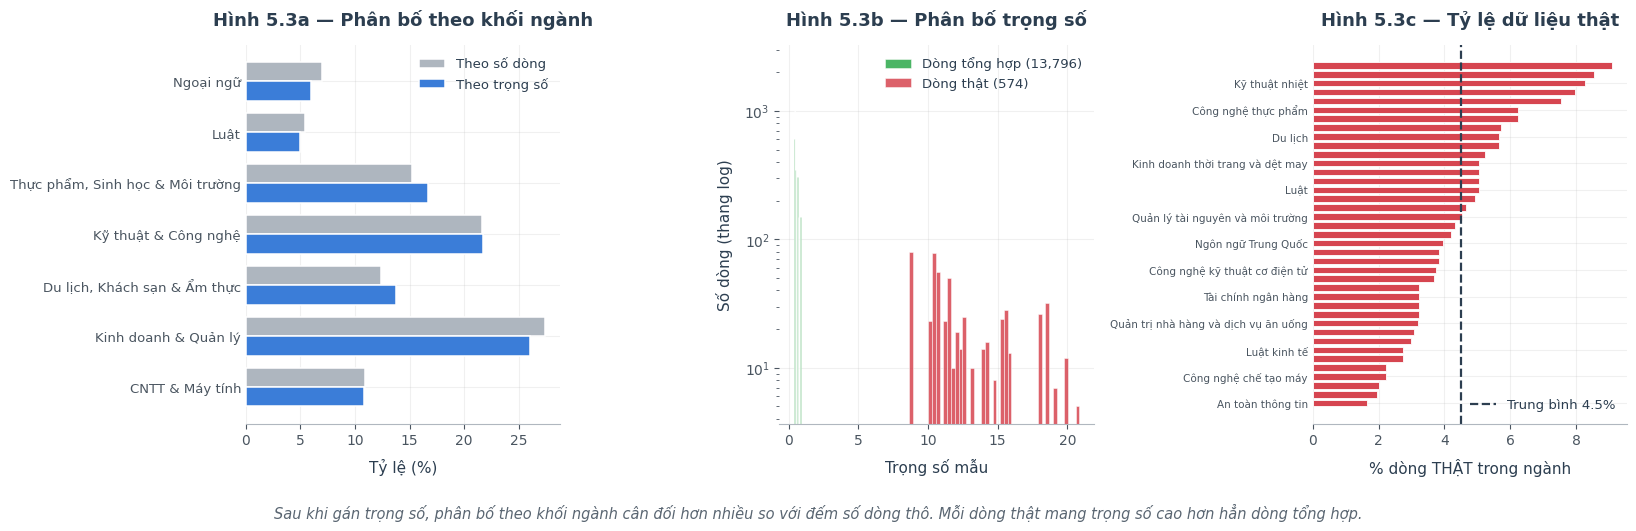

In [6]:
# ═══════════ HÌNH 5.3 — Cơ cấu tập huấn luyện cuối cùng ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

# (a) Theo khối ngành
ax = axes[0]
k_dong = df.groupby("ma_khoi_nganh").size()
k_ts   = df.groupby("ma_khoi_nganh")["sample_weight"].sum()
y = np.arange(7); h = 0.38
ax.barh(y + h/2, (k_dong / k_dong.sum() * 100).values, h, label="Theo số dòng",
        color=C_XAM, edgecolor="white", linewidth=1.1)
ax.barh(y - h/2, (k_ts / k_ts.sum() * 100).values, h, label="Theo trọng số",
        color=C_XANH, edgecolor="white", linewidth=1.1)
ax.set_yticks(y); ax.set_yticklabels([TEN_KHOI[i] for i in range(7)], fontsize=9.5)
ax.set_xlabel("Tỷ lệ (%)")
ax.set_title("Hình 5.3a — Phân bố theo khối ngành")
ax.legend(fontsize=9.5); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (b) Phân bố trọng số mẫu
ax = axes[1]
ax.hist(df.loc[df.is_real == 0, "sample_weight"], bins=45, color=C_GA, alpha=0.85,
        label=f"Dòng tổng hợp ({n_synth:,})", edgecolor="white", linewidth=0.4)
ax.hist(df.loc[df.is_real == 1, "sample_weight"], bins=45, color=C_THAT, alpha=0.85,
        label=f"Dòng thật ({n_that})", edgecolor="white", linewidth=0.4)
ax.set_yscale("log"); ax.set_xlabel("Trọng số mẫu"); ax.set_ylabel("Số dòng (thang log)")
ax.set_title("Hình 5.3b — Phân bố trọng số")
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (c) Nguồn dữ liệu theo ngành
ax = axes[2]
bang = pd.DataFrame({
    "that": df[df.is_real == 1].groupby("ma_nganh").size(),
    "ga":   df[df.is_real == 0].groupby("ma_nganh").size()}).fillna(0)
bang["ty_le_that"] = bang["that"] / (bang["that"] + bang["ga"]) * 100
bang = bang.sort_values("ty_le_that")
ax.barh(range(39), bang["ty_le_that"].values, height=0.74, color=C_THAT,
        edgecolor="white", linewidth=0.6)
ax.axvline(bang["ty_le_that"].mean(), color=C_DAM, ls="--", lw=1.6,
           label=f"Trung bình {bang['ty_le_that'].mean():.1f}%")
ax.set_yticks(range(0, 39, 3))
ax.set_yticklabels([MA_TO_TEN[m] for m in bang.index[::3]], fontsize=7.5)
ax.set_xlabel("% dòng THẬT trong ngành")
ax.set_title("Hình 5.3c — Tỷ lệ dữ liệu thật")
ax.legend(fontsize=9.5); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_5_3_co_cau_tap_huan_luyen.png",
    "Sau khi gán trọng số, phân bố theo khối ngành cân đối hơn nhiều so với đếm số dòng thô. "
    "Mỗi dòng thật mang trọng số cao hơn hẳn dòng tổng hợp.")
plt.show()

In [7]:
ts_nganh = df.groupby("ma_nganh")["sample_weight"].sum()
bang_ct = pd.DataFrame({
    "Khối ngành":    [TEN_KHOI[df.loc[df.ma_nganh == m, "ma_khoi_nganh"].iloc[0]] for m in bang.index],
    "Dòng thật":     bang["that"].astype(int).values,
    "Dòng GA":       bang["ga"].astype(int).values,
    "% thật":        bang["ty_le_that"].round(1).values,
    "Tổng trọng số": ts_nganh.reindex(bang.index).round(0).astype(int).values,
}, index=[MA_TO_TEN[m] for m in bang.index]).sort_values("Dòng thật")

print("BẢNG 5.2 — Cơ cấu dữ liệu và trọng số theo từng ngành\n")
print(bang_ct.to_string())

print("\n" + "═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 5")
print("═" * 68)
print(f"  Tổng dòng huấn luyện          {len(df):>10,}")
print(f"  ├─ Khảo sát thật              {n_that:>10,}   ({n_that/len(df):.1%} số dòng)")
print(f"  └─ Tổng hợp GA                {n_synth:>10,}   ({n_synth/len(df):.1%} số dòng)")
print(f"  Trọng số nguồn cho dòng thật  {w_that:>10.2f}")
print(f"  Tỷ lệ trọng số thật/tổng hợp  {'50 : 50':>10}")
print(f"  Chênh lệch trọng số giữa ngành{ch_truoc:>9.1f}× → {ch_sau:.1f}×")
print("═" * 68)
print(f"\n  Hình đã lưu tại: {OUTPUT_DIR}/")

BẢNG 5.2 — Cơ cấu dữ liệu và trọng số theo từng ngành

                                                               Khối ngành  Dòng thật  Dòng GA  % thật  Tổng trọng số
Công nghệ kỹ thuật môi trường            Thực phẩm, Sinh học & Môi trường          5      150     3.2            234
Công nghệ chế biến thủy sản              Thực phẩm, Sinh học & Môi trường          6      150     3.8            245
Quản lý Công nghiệp                                  Kinh doanh & Quản lý          6      150     3.8            245
Khoa học chế biến món ăn                     Du lịch, Khách sạn & Ẩm thực          7      155     4.3            256
Quản lý tài nguyên và môi trường         Thực phẩm, Sinh học & Môi trường          8      169     4.5            271
Luật                                                                 Luật          8      150     5.1            264
Quản trị kinh doanh thực phẩm            Thực phẩm, Sinh học & Môi trường          8      349     2.2            332
Khoa học 